In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [2]:
# archivo1 = "Flux_xy_z1_10.out"
# archivo2 = "Flux_xy_z465.out"

nx = 134
ny = 134

xmin, xmax = -6.67, 6.67
ymin, ymax = -6.67, 6.67

def leer_matriz_phits(nombre, nx, ny):
    valores = []
    leer = False

    with open(nombre, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if linea.strip().startswith("hc:"):
                leer = True
                continue

            if leer:
                if linea.strip() == "":
                    continue

                partes = linea.split()
                for p in partes:
                    try:
                        valores.append(float(p.replace("D", "E")))
                    except:
                        pass

                if len(valores) >= nx * ny:
                    break

    datos = np.array(valores[:nx * ny])
    matriz = datos.reshape((ny, nx))
    return matriz

flujo1 = leer_matriz_phits(archivo1, nx, ny)
flujo2 = leer_matriz_phits(archivo2, nx, ny)

dif = flujo2 - flujo1

vmin = min(flujo1.min(), flujo2.min())
vmax = max(flujo1.max(), flujo2.max())

plt.figure(figsize=(7,6))
plt.imshow(flujo1, extent=[xmin, xmax, ymin, ymax], origin="lower", aspect="equal", vmin=vmin, vmax=vmax)
plt.colorbar(label="Flujo [1/cm²/source]")
plt.title("Flujo de partículas en XY, z ≈ 1.10 cm")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.show()

plt.figure(figsize=(7,6))
plt.imshow(flujo2, extent=[xmin, xmax, ymin, ymax], origin="lower", aspect="equal", vmin=vmin, vmax=vmax)
plt.colorbar(label="Flujo [1/cm²/source]")
plt.title("Flujo de partículas en XY, z ≈ 4.65 cm")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.show()


NameError: name 'archivo1' is not defined

C:\Users\FIUBA\AppData\Local\Temp\ipykernel_33712\1896422717.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


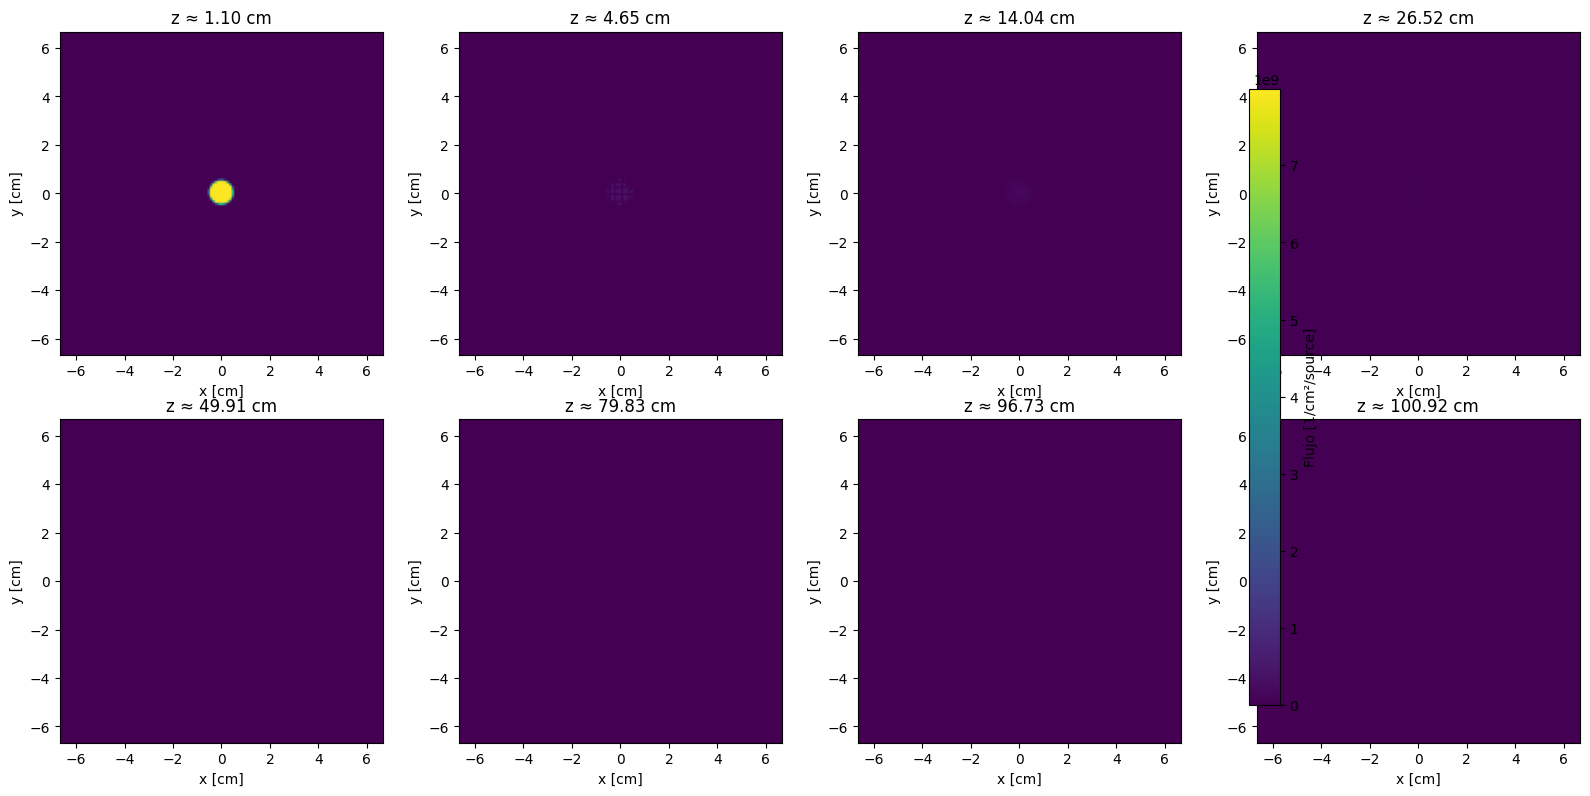

In [ ]:
""" archivos = [
    ("Flux_xy_z1_10.out", "z ≈ 1.10 cm"),
    ("Flux_xy_z465.out", "z ≈ 4.65 cm"),
    ("Flux_xy_z14_04.out", "z ≈ 14.04 cm"),
    ("Flux_xy_z26_52.out", "z ≈ 26.52 cm"),
    ("Flux_xy_z49_91.out", "z ≈ 49.91 cm"),
    ("Flux_xy_z79_83.out", "z ≈ 79.83 cm"),
    ("Flux_xy_z96_73.out", "z ≈ 96.73 cm"),
    ("Flux_xy_z100_92.out", "z ≈ 100.92 cm"),
]
"""

nx = 134
ny = 134

xmin, xmax = -6.67, 6.67
ymin, ymax = -6.67, 6.67

def leer_matriz_phits(nombre, nx, ny):
    valores = []
    leer = False

    with open(nombre, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if linea.strip().startswith("hc:"):
                leer = True
                continue

            if leer:
                if linea.strip() == "":
                    continue

                for p in linea.split():
                    try:
                        valores.append(float(p.replace("D", "E")))
                    except:
                        pass

                if len(valores) >= nx * ny:
                    break

    datos = np.array(valores[:nx * ny])
    return datos.reshape((ny, nx))

# Leer todos los datos
flujos = []
for archivo, _ in archivos:
    flujos.append(leer_matriz_phits(archivo, nx, ny))

# Escala común (MUY importante)
vmin = min(f.min() for f in flujos)
vmax = max(f.max() for f in flujos)

# Grid de plots
n = len(archivos)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
axes = axes.flatten()

for i, ((archivo, titulo), flujo) in enumerate(zip(archivos, flujos)):
    im = axes[i].imshow(
        flujo,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )
    axes[i].set_title(titulo)
    axes[i].set_xlabel("x [cm]")
    axes[i].set_ylabel("y [cm]")

# borrar subplots vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.colorbar(im, ax=axes, label="Flujo [1/cm²/source]")
plt.tight_layout()
plt.show()

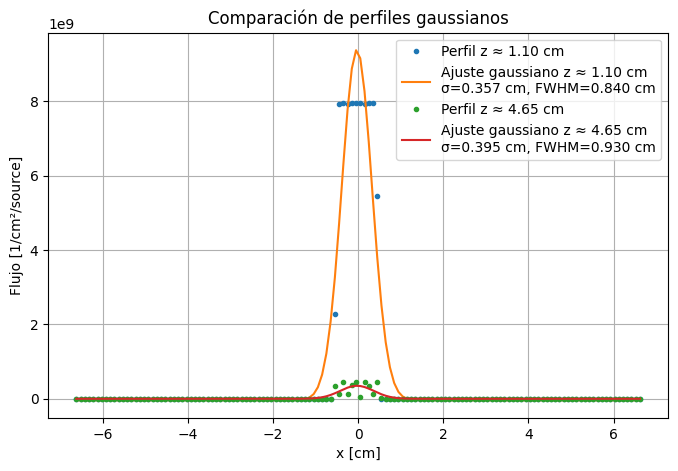

z ≈ 1.10 cm
A = 9.43092e+09
x0 = -0.0298161 cm
sigma = 0.356897 cm
FWHM = 0.840428 cm
C = -4.05877e+07

z ≈ 4.65 cm
A = 3.49955e+08
x0 = -0.0284576 cm
sigma = 0.395144 cm
FWHM = 0.930492 cm
C = -1.65427e+06


In [ ]:
# archivo1 = "Flux_xy_z1_10.out"
# archivo2 = "Flux_xy_z465.out"

""" nx = 134
ny = 134
xmin, xmax = -6.67, 6.67
 """

def leer_matriz_phits(nombre, nx, ny):
    valores = []
    leer = False

    with open(nombre, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if linea.strip().startswith("hc:"):
                leer = True
                continue
            if leer:
                if linea.strip() == "":
                    continue
                for p in linea.split():
                    try:
                        valores.append(float(p.replace("D", "E")))
                    except:
                        pass
                if len(valores) >= nx * ny:
                    break

    datos = np.array(valores[:nx * ny])
    return datos.reshape((ny, nx))

def gaussiana(x, A, x0, sigma, C):
    return A * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) + C

flujo1 = leer_matriz_phits(archivo1, nx, ny)
flujo2 = leer_matriz_phits(archivo2, nx, ny)

x = np.linspace(xmin + (xmax - xmin)/(2*nx), xmax - (xmax - xmin)/(2*nx), nx)

iy = ny // 2
perfil1 = flujo1[iy, :]
perfil2 = flujo2[iy, :]

p0_1 = [perfil1.max() - perfil1.min(), x[np.argmax(perfil1)], 1.0, perfil1.min()]
p0_2 = [perfil2.max() - perfil2.min(), x[np.argmax(perfil2)], 1.0, perfil2.min()]

params1, _ = curve_fit(gaussiana, x, perfil1, p0=p0_1, maxfev=10000)
params2, _ = curve_fit(gaussiana, x, perfil2, p0=p0_2, maxfev=10000)

A1, x01, sigma1, C1 = params1
A2, x02, sigma2, C2 = params2

ajuste1 = gaussiana(x, *params1)
ajuste2 = gaussiana(x, *params2)

fwhm1 = 2 * np.sqrt(2 * np.log(2)) * abs(sigma1)
fwhm2 = 2 * np.sqrt(2 * np.log(2)) * abs(sigma2)

plt.figure(figsize=(8, 5))
plt.plot(x, perfil1, "o", ms=3, label="Perfil z ≈ 1.10 cm")
plt.plot(x, ajuste1, "-", label=f"Ajuste gaussiano z ≈ 1.10 cm\nσ={sigma1:.3f} cm, FWHM={fwhm1:.3f} cm")
plt.plot(x, perfil2, "o", ms=3, label="Perfil z ≈ 4.65 cm")
plt.plot(x, ajuste2, "-", label=f"Ajuste gaussiano z ≈ 4.65 cm\nσ={sigma2:.3f} cm, FWHM={fwhm2:.3f} cm")
plt.xlabel("x [cm]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Comparación de perfiles gaussianos")
plt.grid(True)
plt.legend()
plt.show()

print("z ≈ 1.10 cm")
print(f"A = {A1:.6g}")
print(f"x0 = {x01:.6g} cm")
print(f"sigma = {sigma1:.6g} cm")
print(f"FWHM = {fwhm1:.6g} cm")
print(f"C = {C1:.6g}")
print()
print("z ≈ 4.65 cm")
print(f"A = {A2:.6g}")
print(f"x0 = {x02:.6g} cm")
print(f"sigma = {sigma2:.6g} cm")
print(f"FWHM = {fwhm2:.6g} cm")
print(f"C = {C2:.6g}")

In [ ]:
# x_0: centro del haz; sigma: ancho gaussiano; FWHM: ancho a mitad de altura; A: altura máxima; C: valor de fondo

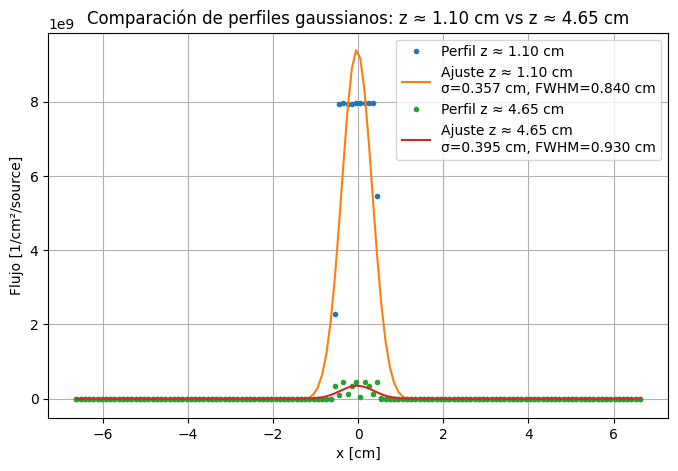

Comparación: z ≈ 1.10 cm vs z ≈ 4.65 cm
z ≈ 1.10 cm
A = 9.4412e+09
x0 = -0.029504 cm
sigma = 0.356682 cm
FWHM = 0.839921 cm
C = -4.05747e+07

z ≈ 4.65 cm
A = 3.51052e+08
x0 = -0.0255262 cm
sigma = 0.39514 cm
FWHM = 0.930483 cm
C = -1.65851e+06
------------------------------------------------------------


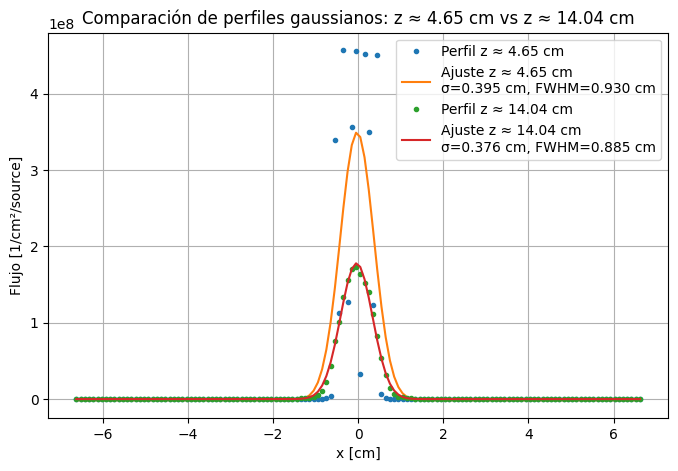

Comparación: z ≈ 4.65 cm vs z ≈ 14.04 cm
z ≈ 4.65 cm
A = 3.51052e+08
x0 = -0.0255262 cm
sigma = 0.39514 cm
FWHM = 0.930483 cm
C = -1.65851e+06

z ≈ 14.04 cm
A = 1.77931e+08
x0 = -0.0384038 cm
sigma = 0.376028 cm
FWHM = 0.885478 cm
C = -178292
------------------------------------------------------------


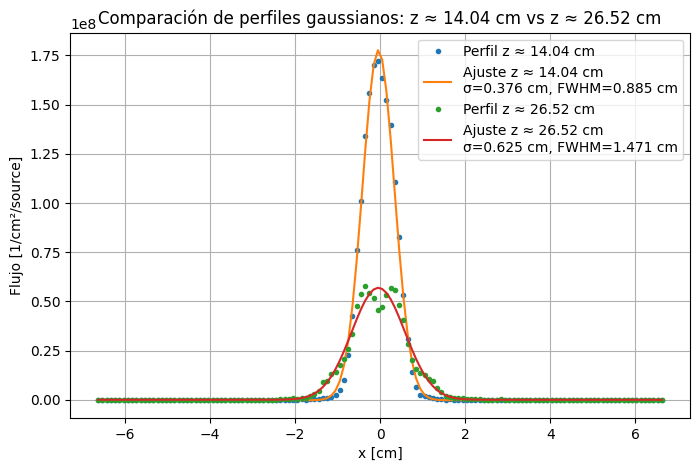

Comparación: z ≈ 14.04 cm vs z ≈ 26.52 cm
z ≈ 14.04 cm
A = 1.77931e+08
x0 = -0.0384038 cm
sigma = 0.376028 cm
FWHM = 0.885478 cm
C = -178292

z ≈ 26.52 cm
A = 5.69158e+07
x0 = -0.0403146 cm
sigma = 0.624683 cm
FWHM = 1.47102 cm
C = 42840.1
------------------------------------------------------------


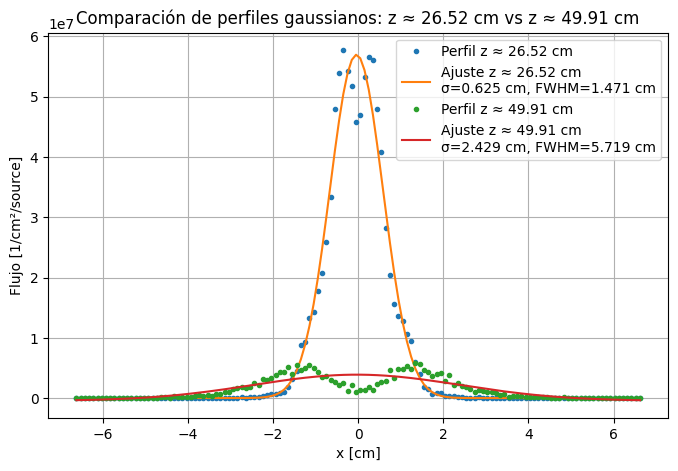

Comparación: z ≈ 26.52 cm vs z ≈ 49.91 cm
z ≈ 26.52 cm
A = 5.69158e+07
x0 = -0.0403146 cm
sigma = 0.624683 cm
FWHM = 1.47102 cm
C = 42840.1

z ≈ 49.91 cm
A = 4.33907e+06
x0 = -0.0332724 cm
sigma = 2.42876 cm
FWHM = 5.71929 cm
C = -414601
------------------------------------------------------------


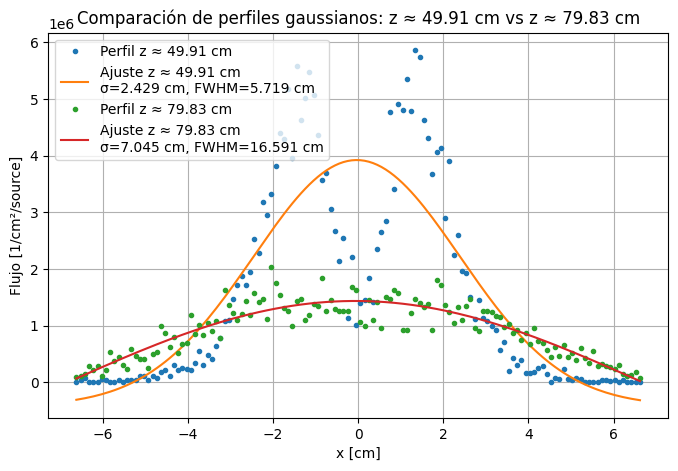

Comparación: z ≈ 49.91 cm vs z ≈ 79.83 cm
z ≈ 49.91 cm
A = 4.33907e+06
x0 = -0.0332724 cm
sigma = 2.42876 cm
FWHM = 5.71929 cm
C = -414601

z ≈ 79.83 cm
A = 3.89573e+06
x0 = -0.0697036 cm
sigma = 7.04544 cm
FWHM = 16.5907 cm
C = -2.45763e+06
------------------------------------------------------------


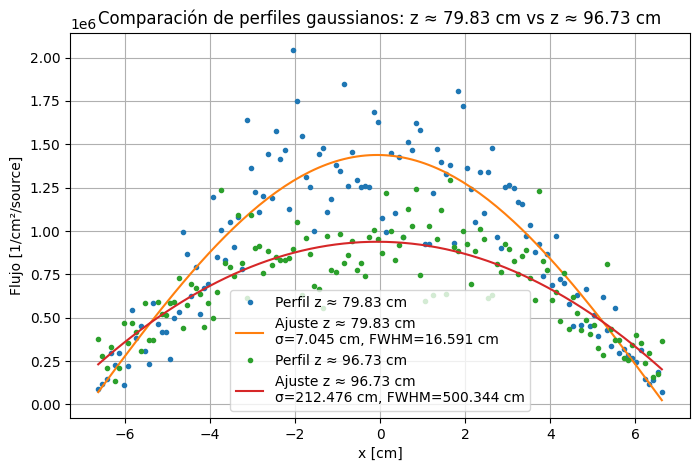

Comparación: z ≈ 79.83 cm vs z ≈ 96.73 cm
z ≈ 79.83 cm
A = 3.89573e+06
x0 = -0.0697036 cm
sigma = 7.04544 cm
FWHM = 16.5907 cm
C = -2.45763e+06

z ≈ 96.73 cm
A = 1.48556e+09
x0 = -0.0658423 cm
sigma = 212.476 cm
FWHM = 500.344 cm
C = -1.48463e+09
------------------------------------------------------------


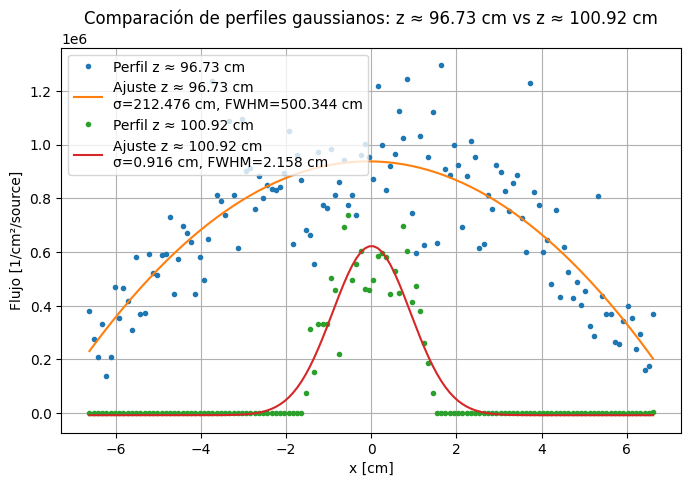

Comparación: z ≈ 96.73 cm vs z ≈ 100.92 cm
z ≈ 96.73 cm
A = 1.48556e+09
x0 = -0.0658423 cm
sigma = 212.476 cm
FWHM = 500.344 cm
C = -1.48463e+09

z ≈ 100.92 cm
A = 630305
x0 = 0.00539403 cm
sigma = 0.91635 cm
FWHM = 2.15784 cm
C = -7759.82
------------------------------------------------------------


In [ ]:
# comparamos todos:

""" archivos = [
    ("Flux_xy_z1_10.out", "z ≈ 1.10 cm"),
    ("Flux_xy_z465.out", "z ≈ 4.65 cm"),
    ("Flux_xy_z14_04.out", "z ≈ 14.04 cm"),
    ("Flux_xy_z26_52.out", "z ≈ 26.52 cm"),
    ("Flux_xy_z49_91.out", "z ≈ 49.91 cm"),
    ("Flux_xy_z79_83.out", "z ≈ 79.83 cm"),
    ("Flux_xy_z96_73.out", "z ≈ 96.73 cm"),
    ("Flux_xy_z100_92.out", "z ≈ 100.92 cm"),
]
 """
nx = 134
ny = 134
xmin, xmax = -6.67, 6.67

def leer_matriz_phits(nombre, nx, ny):
    valores = []
    leer = False

    with open(nombre, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if linea.strip().startswith("hc:"):
                leer = True
                continue
            if leer:
                if linea.strip() == "":
                    continue
                for p in linea.split():
                    try:
                        valores.append(float(p.replace("D", "E")))
                    except:
                        pass
                if len(valores) >= nx * ny:
                    break

    datos = np.array(valores[:nx * ny])
    return datos.reshape((ny, nx))

def gaussiana(x, A, x0, sigma, C):
    return A * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) + C

x = np.linspace(xmin + (xmax - xmin)/(2*nx), xmax - (xmax - xmin)/(2*nx), nx)
iy = ny // 2

for i in range(len(archivos) - 1):
    archivo1, label1 = archivos[i]
    archivo2, label2 = archivos[i + 1]

    flujo1 = leer_matriz_phits(archivo1, nx, ny)
    flujo2 = leer_matriz_phits(archivo2, nx, ny)

    perfil1 = flujo1[iy, :]
    perfil2 = flujo2[iy, :]

    p0_1 = [perfil1.max() - perfil1.min(), x[np.argmax(perfil1)], 1.0, perfil1.min()]
    p0_2 = [perfil2.max() - perfil2.min(), x[np.argmax(perfil2)], 1.0, perfil2.min()]

    params1, _ = curve_fit(gaussiana, x, perfil1, p0=p0_1, maxfev=10000)
    params2, _ = curve_fit(gaussiana, x, perfil2, p0=p0_2, maxfev=10000)

    A1, x01, sigma1, C1 = params1
    A2, x02, sigma2, C2 = params2

    ajuste1 = gaussiana(x, *params1)
    ajuste2 = gaussiana(x, *params2)

    fwhm1 = 2 * np.sqrt(2 * np.log(2)) * abs(sigma1)
    fwhm2 = 2 * np.sqrt(2 * np.log(2)) * abs(sigma2)

    plt.figure(figsize=(8, 5))
    plt.plot(x, perfil1, "o", ms=3, label=f"Perfil {label1}")
    plt.plot(x, ajuste1, "-", label=f"Ajuste {label1}\nσ={sigma1:.3f} cm, FWHM={fwhm1:.3f} cm")
    plt.plot(x, perfil2, "o", ms=3, label=f"Perfil {label2}")
    plt.plot(x, ajuste2, "-", label=f"Ajuste {label2}\nσ={sigma2:.3f} cm, FWHM={fwhm2:.3f} cm")
    plt.xlabel("x [cm]")
    plt.ylabel("Flujo [1/cm²/source]")
    plt.title(f"Comparación de perfiles gaussianos: {label1} vs {label2}")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Comparación: {label1} vs {label2}")
    print(label1)
    print(f"A = {A1:.6g}")
    print(f"x0 = {x01:.6g} cm")
    print(f"sigma = {sigma1:.6g} cm")
    print(f"FWHM = {fwhm1:.6g} cm")
    print(f"C = {C1:.6g}")
    print()
    print(label2)
    print(f"A = {A2:.6g}")
    print(f"x0 = {x02:.6g} cm")
    print(f"sigma = {sigma2:.6g} cm")
    print(f"FWHM = {fwhm2:.6g} cm")
    print(f"C = {C2:.6g}")
    print("-" * 60)